### FASE 3. Análisis Exploratorio de Datos (EDA)

**Proyecto:** Análisis Exploratorio de Datos — Ingresos totales por ventas a clientes de un comercio.

**Objetivo de esta fase:**
Comprender el comportamiento de los datos mediante estadísticas descriptivas y visualizaciones, identificando patrones, relaciones entre variables y, especialmente, qué factores se asocian a un cliente (variable `id_cliente`) que realiza una compra (variable `order_id`).

**Punto de partida:** `02_datos_limpios.csv` (52.000 filas × 39 columnas), resultado de la Fase 2.

**Flujo que seguiremos:**
1. Recordatorio Pre-EDA.
2. Identificar variables categóricas y numéricas.
3. Análisis univariante (categóricas y numéricas).
4. Análisis bivariante — relación con la variable objetivo `y`.
5. Relación entre variables numéricas y correlaciones globales.
6. Evolución temporal.
7. Preguntas de negocio.
8. Conclusiones de la fase.


In [2]:
# Libreria de Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Exploracion de Archivos de soporte
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se

# Para que se muestren todas las columnas al imspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)

#### 1️⃣ COLUMNAS A EXCLUIR


"Antes de iniciar el EDA oficial, se realizó una exploración preliminar completa (eda() sin exclusiones) en un notebook de borrador, no incluido en la entrega, que permitió identificar las columnas a excluir por ser identificadores únicos, texto libre o sin interpretación de negocio directa (cols_excluir). A partir de esa decisión, el EDA oficial parte ya con esa lista aplicada, evitando ruido innecesario en los resultados."

In [4]:
# Columnas a excluir del estudio porque no tienen una correlación numérica
cols_excluir = ['order_id', 'id_cliente', 'product_id', 'nombre_producto',
                 'latitude', 'longitude', 'precio_unitario', 'importe_total']

**Observación**
Se excluyen tres tipos de variables: 
- identificadores únicos `order_id`, `id_cliente`, `product_id)` son identificadores únicos, no son magnitudes comparables.
-  `nombre_producto`es un texto libre con demasiadas variables, no son aplicable a correlación numérica, se puede valorar estudiar de forma independiente. 
- `latitude/longitude`no tienen interpretación de negocio directa.
-  `precio_unitario` e `importe_total`se han creado anterirormenten sus versiones winsorizadas (_wz) y ya están representadas en la matriz, evitando así duplicar la misma información dos veces.

#### 2️⃣ EXPLORACION 

**Objetivo:** Exploracion del dataset, una vez detectadas los valores a excluir, realizamos una exploracion de estos

#### Creamos el df_pedidos

In [5]:
df_pedidos = df 

#### Calidad de datos

In [6]:
se.exploracion (df_pedidos,cols_excluir=cols_excluir)

PRIMERAS COLUMNAS


,1113,649,48260
fecha_pedido,2022-02-13 00:00:00,2022-01-04 00:00:00,2025-12-14 00:00:00
cantidad,1,2,4
descuento,0.0,0.0,0.0
metodo_pago,tarjeta de debito,paypal,transferencia
envio_gratis,no,si,no
calificacion,4.0,5.0,4.0
devuelto,no,no,no
canal,web,tienda fisica,app movil
año_ventas,2022,2022,2025
categoria_producto,electronica,hogar,hogar


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
INFORMACIÓN BÁSICA
<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha_pedido              52000 non-null  datetime64[us]
 1   cantidad                  52000 non-null  int64         
 2   descuento                 52000 non-null  float64       
 3   metodo_pago               52000 non-null  str           
 4   envio_gratis              52000 non-null  str           
 5   calificacion              52000 non-null  float64       
 6   devuelto                  52000 non-null  str           
 7   canal                     52000 non-null  str           
 8   año_ventas                52000 non-null  int64         
 9   categoria_producto        52000 non-null  str           
 10  marca                     52000 n

None

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
ESTADISTICOS


...

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
TAMAÑO DATAFRAME
(52000, 31)
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
NULOS


fecha_registro    253
dtype: int64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
PORCENTAJE DE NULOS


fecha_registro    0.49
dtype: float64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
DUPLICADOS
0


**Observación:** 
- Se observa que no hay nulos y la coluna `fecha_registo` se valoro en fase anterior que dado el bajo volumen de nulos (0.49% del total) y la ausencia de una causa clara y verificable, se decide no imputar y mantener los valores como NaT, evitando introducir una fecha sintética sin respaldo.

VARIABLES NUMERICAS:

 Index(['cantidad', 'descuento', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

VARIABLES CATEGORICAS:

 Index(['metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

VARIABLES DATETIME(FECHA):

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

VARIABLES NUMERICAS:
                            count      mean       std       min       25%       50%       75%        max
cantidad                  52000.0      2.05      1.20      1.00      1.00      2.00      3.00       5.00
descuento                 52000.0      0.07      0.08      0.00      0.00      0

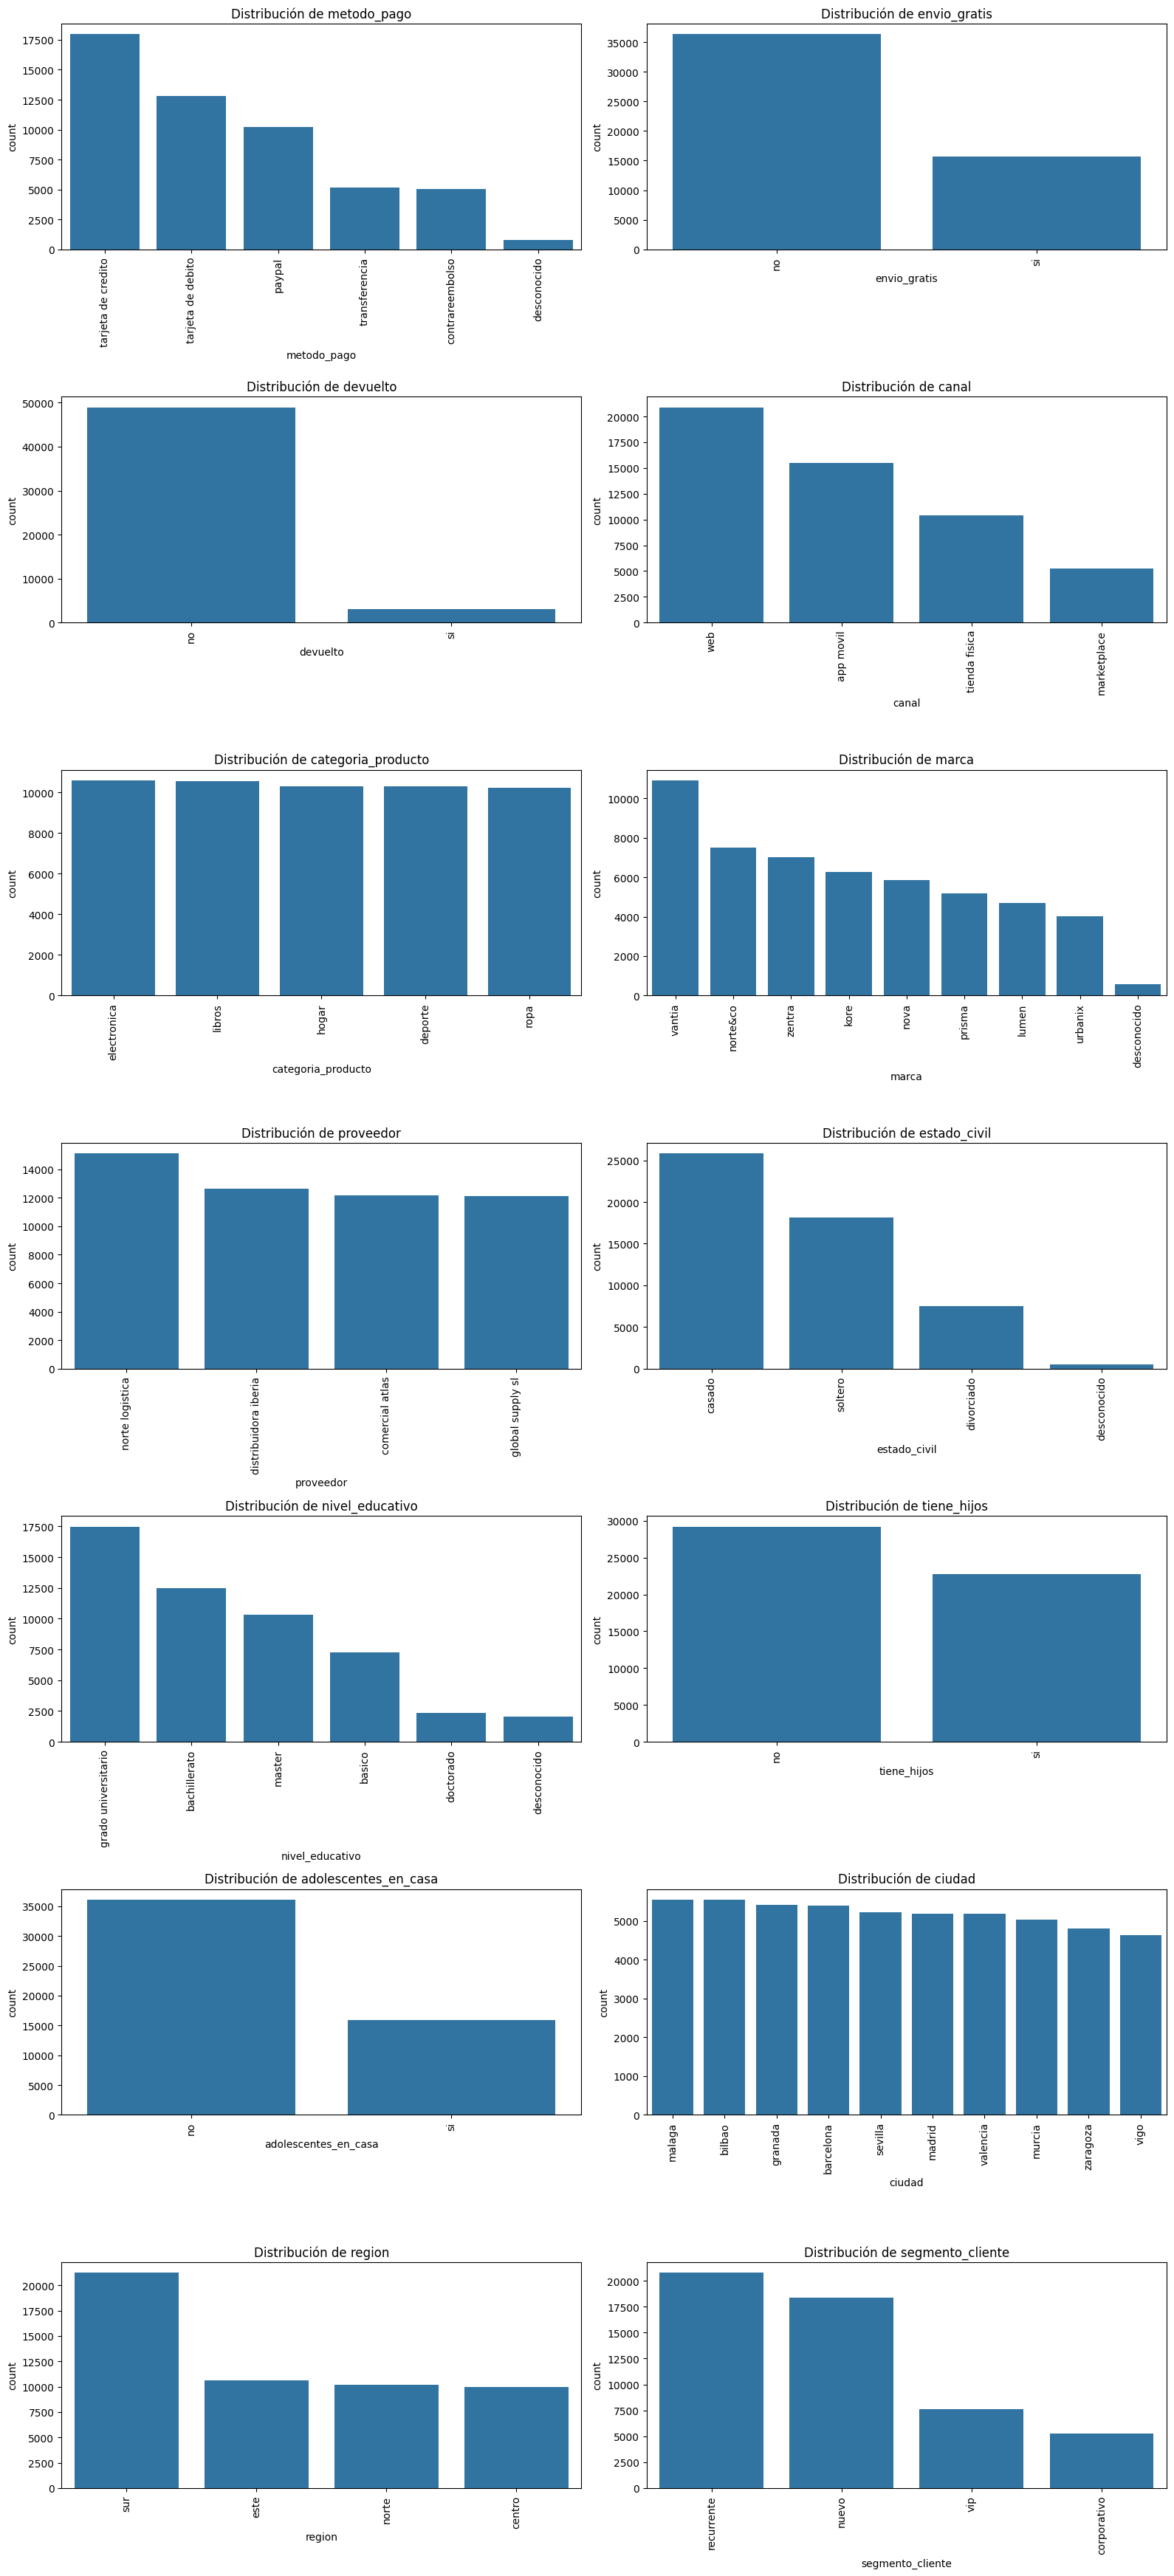


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


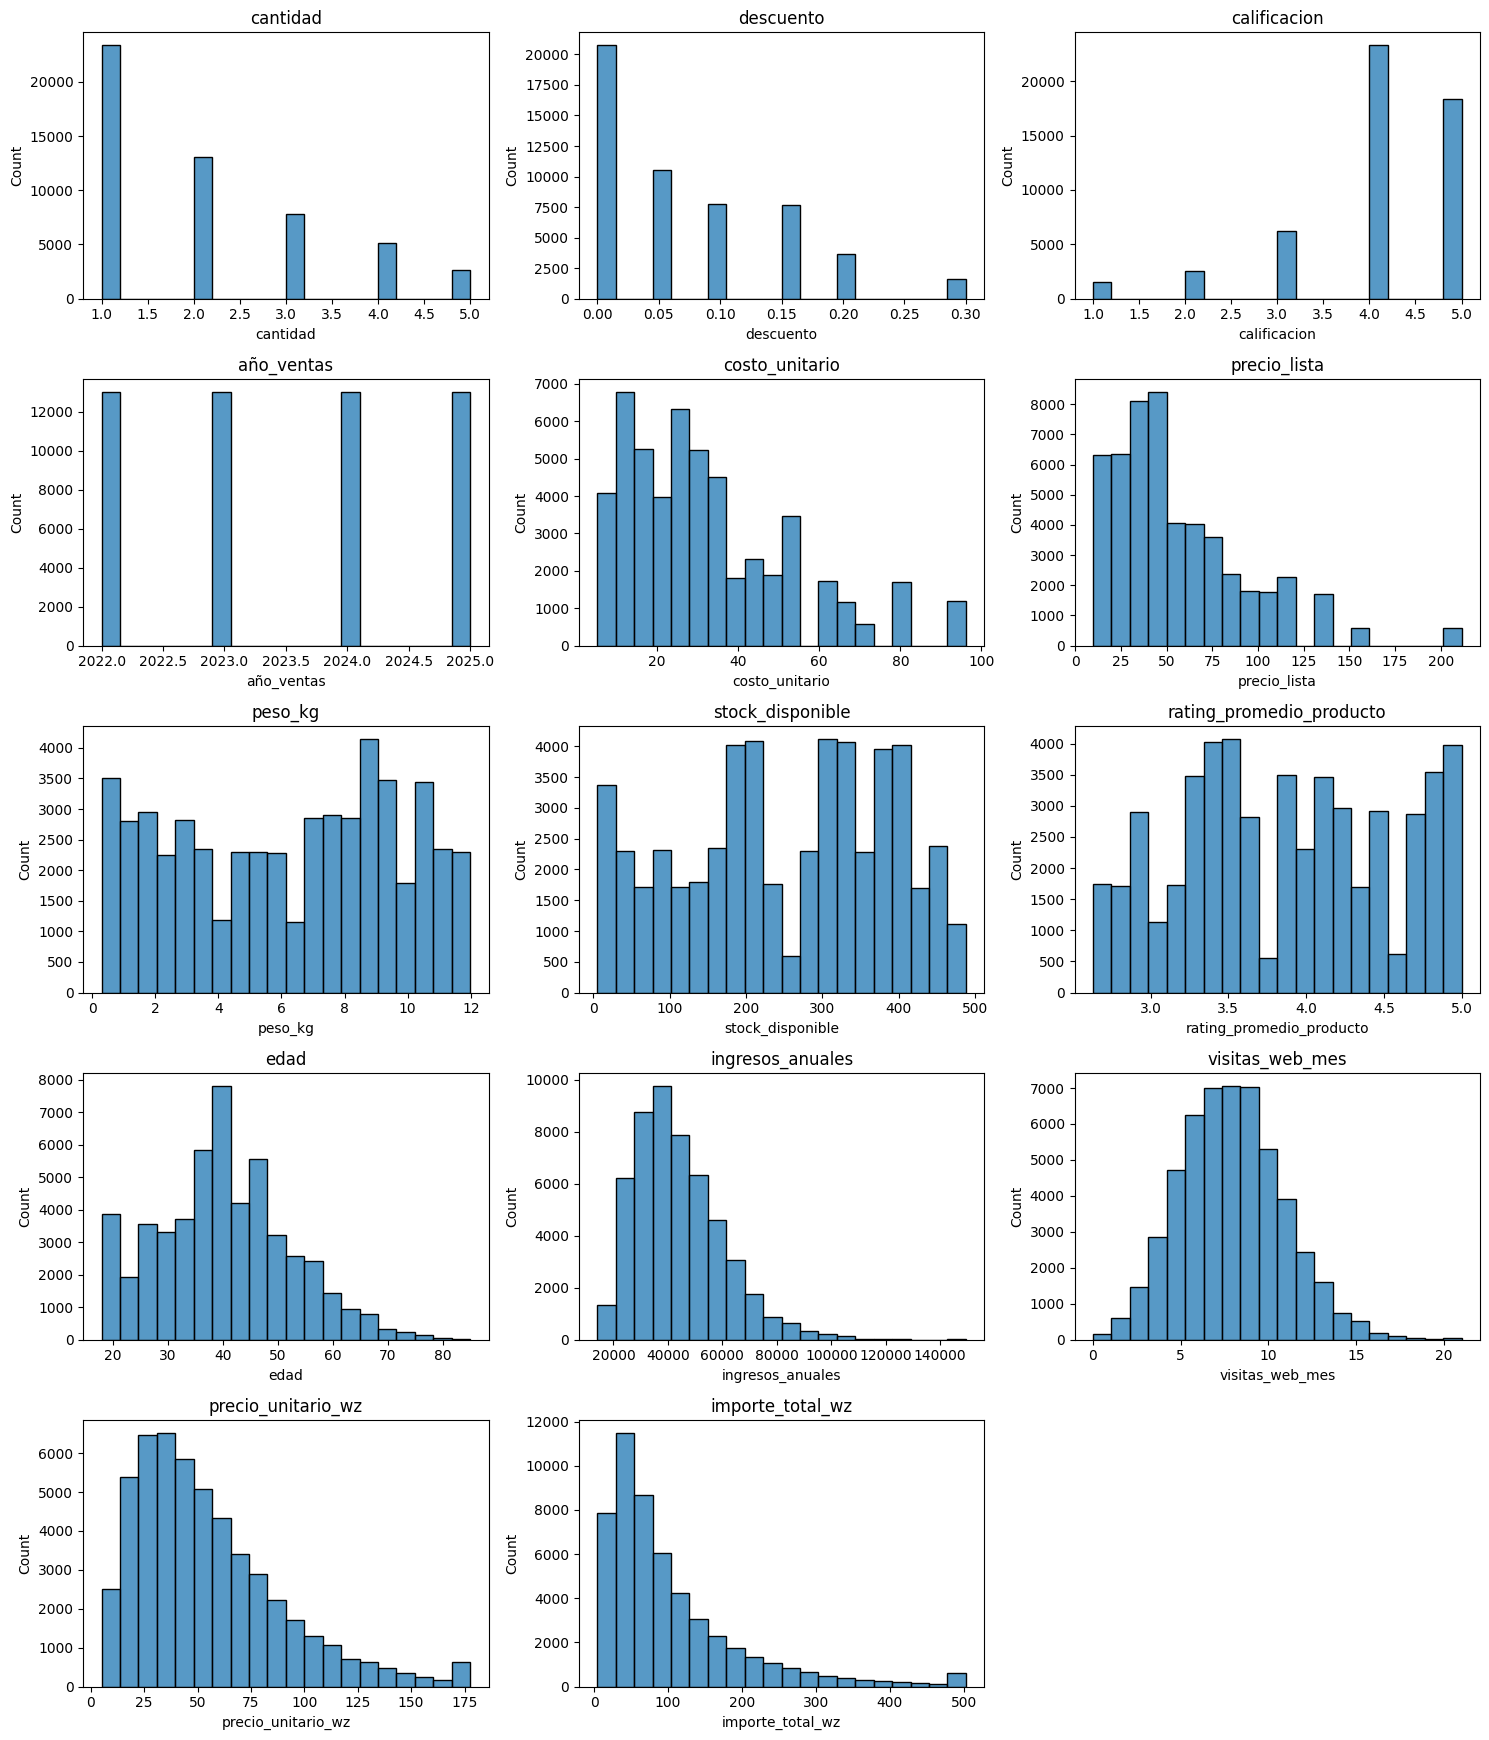


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


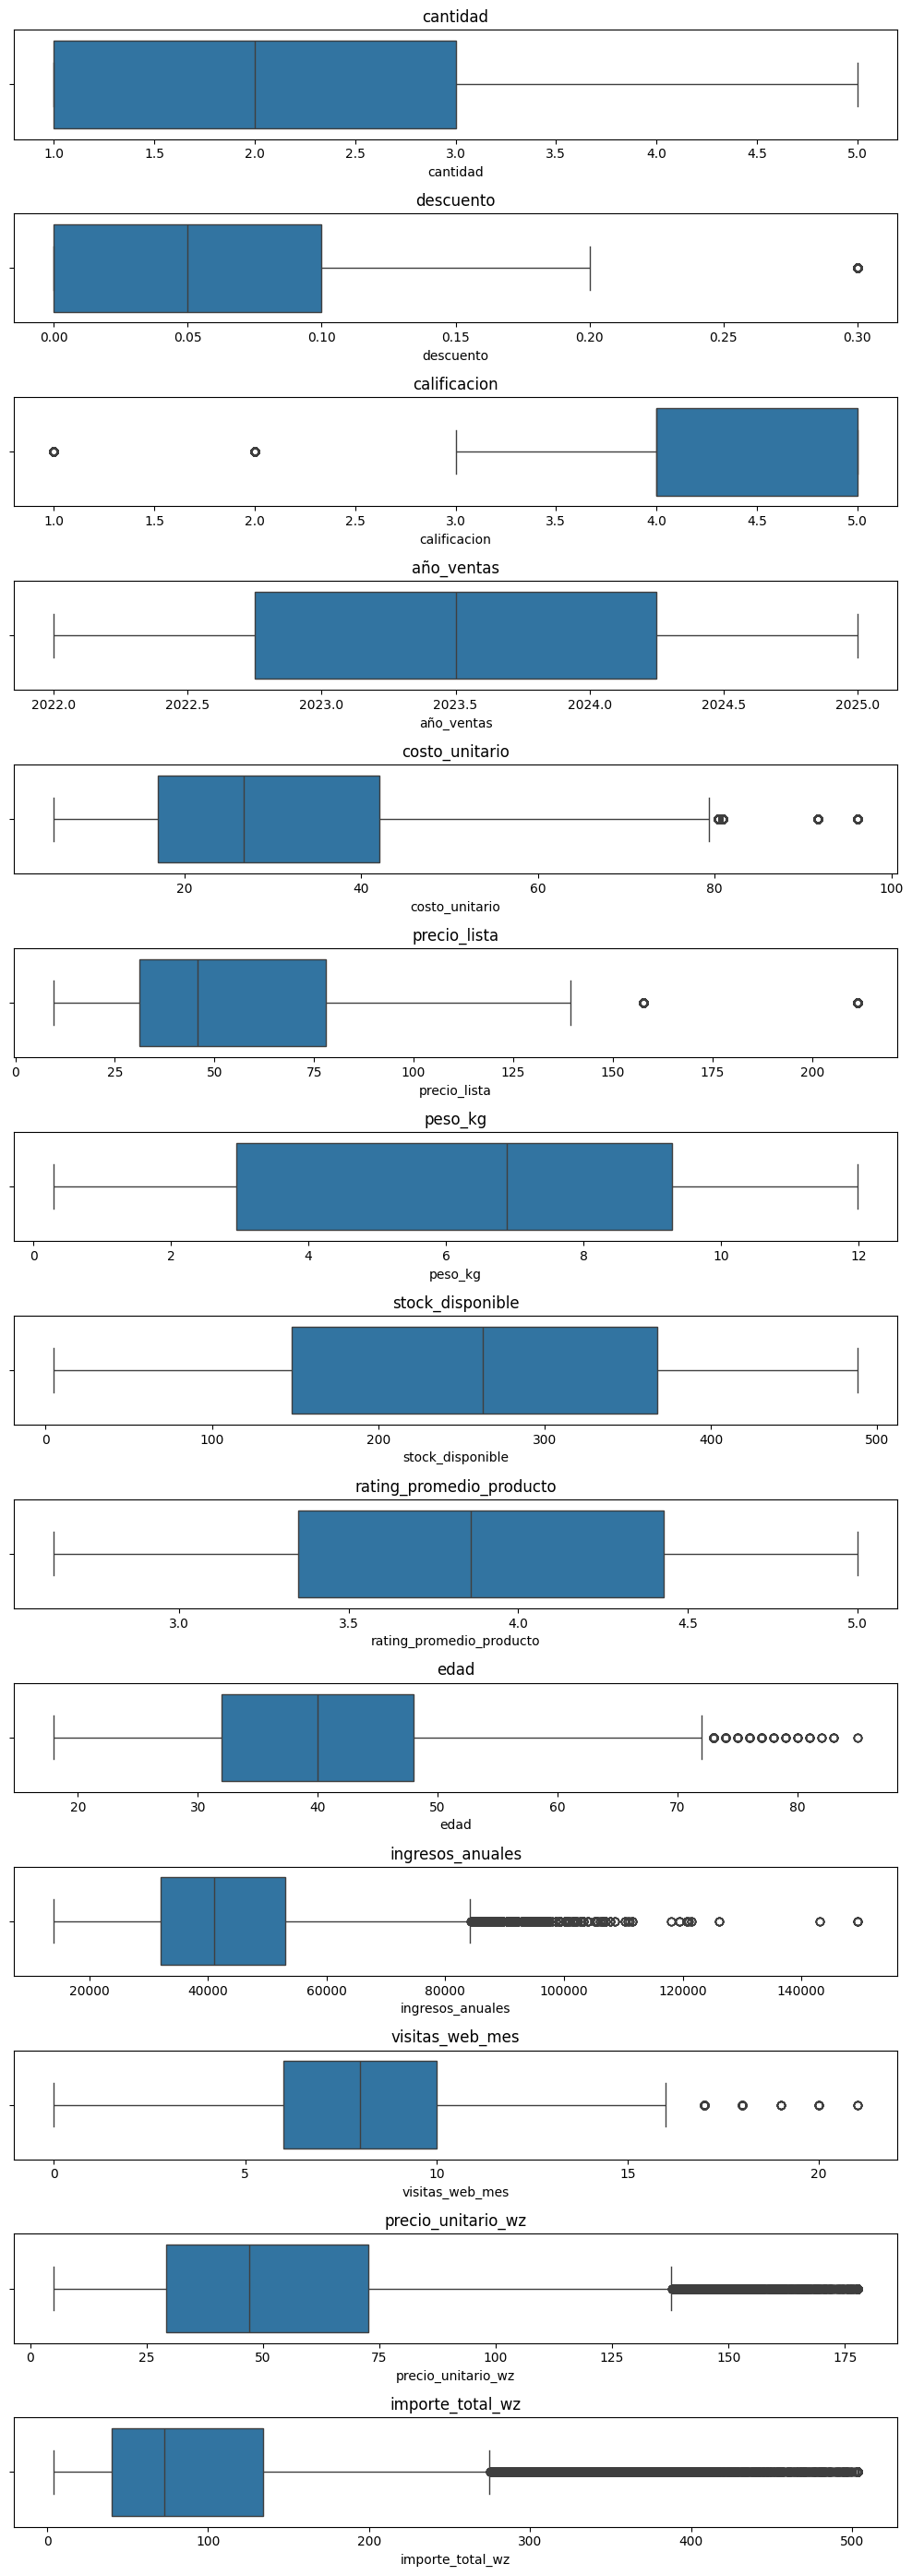

In [7]:
# Realizamos un visual rápida de todas las variables sin las columnas exclidas
se.eda(df_pedidos, cols_excluir=cols_excluir)

### Variables numéricas

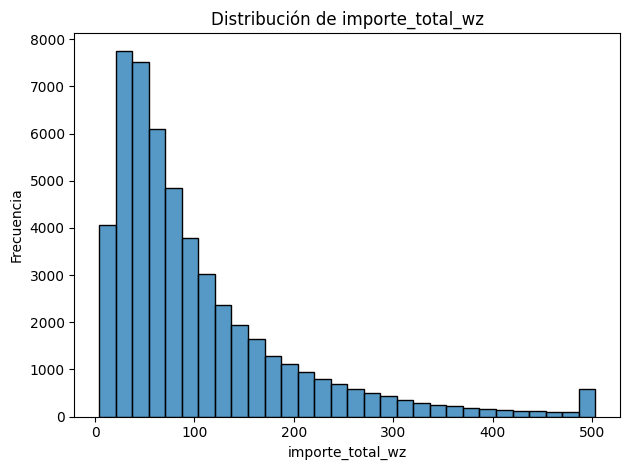

count    52000.00
mean       104.17
std         95.15
min          4.22
25%         40.02
50%         72.52
75%        133.94
max        503.06
Name: importe_total_wz, dtype: float64
........................................


In [8]:
se.histplot(df_pedidos, "importe_total_wz")

**Observación:** <br>
La distribución de `importe_total_wz` está claramente sesgada a la 
derecha: la mayoría de pedidos se concentra entre 20€ y 150€ (coherente 
con la mediana de 72,52€), con una cola larga hacia importes altos. La 
media (104,17€) es notablemente superior a la mediana (72,52€), lo que 
confirma la asimetría — unos pocos pedidos de importe alto están 
"tirando" de la media hacia arriba.

Se observa además un pico anómalo justo en 500€, que no representa un 
patrón real de compra: es resultado del proceso de winsorizing 
aplicado en la fase de limpieza, donde todos los valores que superaban 
ese límite se agruparon en el tope máximo (503,06€).

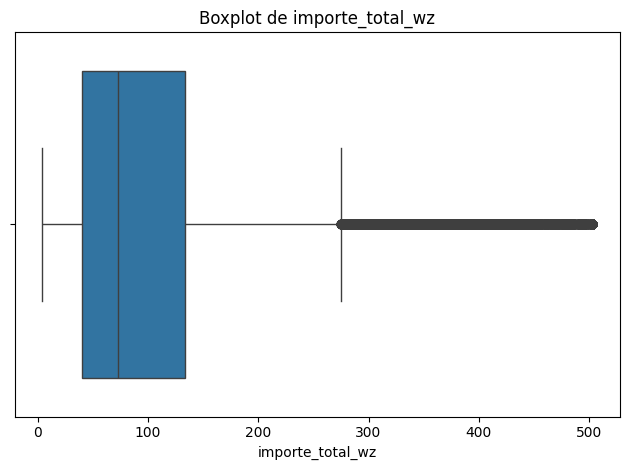

count    52000.00
mean       104.17
std         95.15
min          4.22
25%         40.02
50%         72.52
75%        133.94
max        503.06
Name: importe_total_wz, dtype: float64


In [9]:
se.boxplot(df_pedidos, "importe_total_wz")

**Observación**<br>
Tal como se identificó al inicio del Eda El boxplot confirma la asimetría: la caja (Q1=40,02€, Q3=133,94€) está 
desplazada hacia la izquierda, con el bigote superior más largo que el 
inferior. La masa de puntos "outlier" acumulada justo en el límite 
derecho (~503€) no son outliers dispersos como cabría esperar, sino el 
mismo efecto del winsorizing: al capar los valores extremos en un techo 
fijo, muchos pedidos distintos terminan con el mismo valor máximo, 
generando esa acumulación visual característica en línea recta. No debe 
interpretarse como que hay cientos de pedidos "atípicos" en sentido 
tradicional, sino como el resultado esperable de la técnica de limpieza 
aplicada previamente.

### Variables categóricas

In [10]:
for col in ["canal", "metodo_pago"]:
    conteo = df_pedidos[col].value_counts()
    porcentaje = df_pedidos[col].value_counts(normalize=True).mul(100).round(2)

    resultado = pd.DataFrame({
        "Cantidad": conteo,
        "Porcentaje": porcentaje
    })

    print(resultado)
    print("-" * 40)

               Cantidad  Porcentaje
canal                              
web               20887       40.17
app movil         15498       29.80
tienda fisica     10380       19.96
marketplace        5235       10.07
----------------------------------------
                    Cantidad  Porcentaje
metodo_pago                             
tarjeta de credito     17964       34.55
tarjeta de debito      12825       24.66
paypal                 10219       19.65
transferencia           5181        9.96
contrareembolso         5031        9.68
desconocido              780        1.50
----------------------------------------


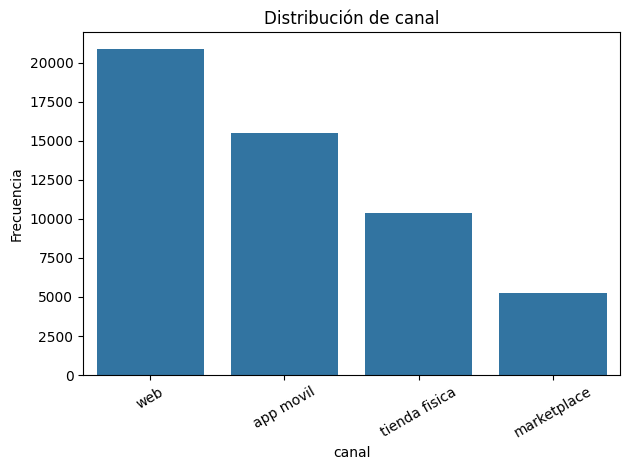

canal
web              20887
app movil        15498
tienda fisica    10380
marketplace       5235
Name: count, dtype: int64
........................................
PORCENTAJES
canal
web              40.17
app movil        29.80
tienda fisica    19.96
marketplace      10.07
Name: proportion, dtype: float64


In [11]:
se.countplot(df_pedidos, "canal")

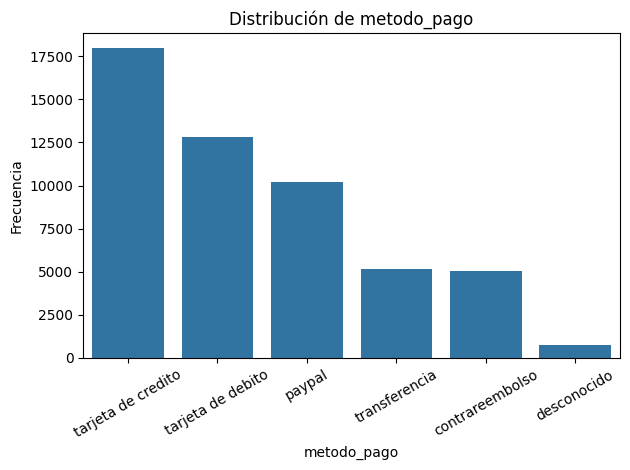

metodo_pago
tarjeta de credito    17964
tarjeta de debito     12825
paypal                10219
transferencia          5181
contrareembolso        5031
desconocido             780
Name: count, dtype: int64
........................................
PORCENTAJES
metodo_pago
tarjeta de credito    34.55
tarjeta de debito     24.66
paypal                19.65
transferencia          9.96
contrareembolso        9.68
desconocido            1.50
Name: proportion, dtype: float64


In [12]:
se.countplot(df_pedidos, "metodo_pago")

**Observación:** 
- `Canal`: web domina claramente (20.887, ~40% del total), seguido de app movil (15.498). tienda fisica y marketplace quedan bastante más atrás, por lo tanto el negocio es mayoritariamente digital (web + app suman ~70% de los pedidos)

- `Método de pago`: tarjeta de credito es el preferido (17.964), seguido de débito y PayPal. Un detalle a anotar: hay 780 registros como "desconocido" (~1.5% del total)

### Correlaciones

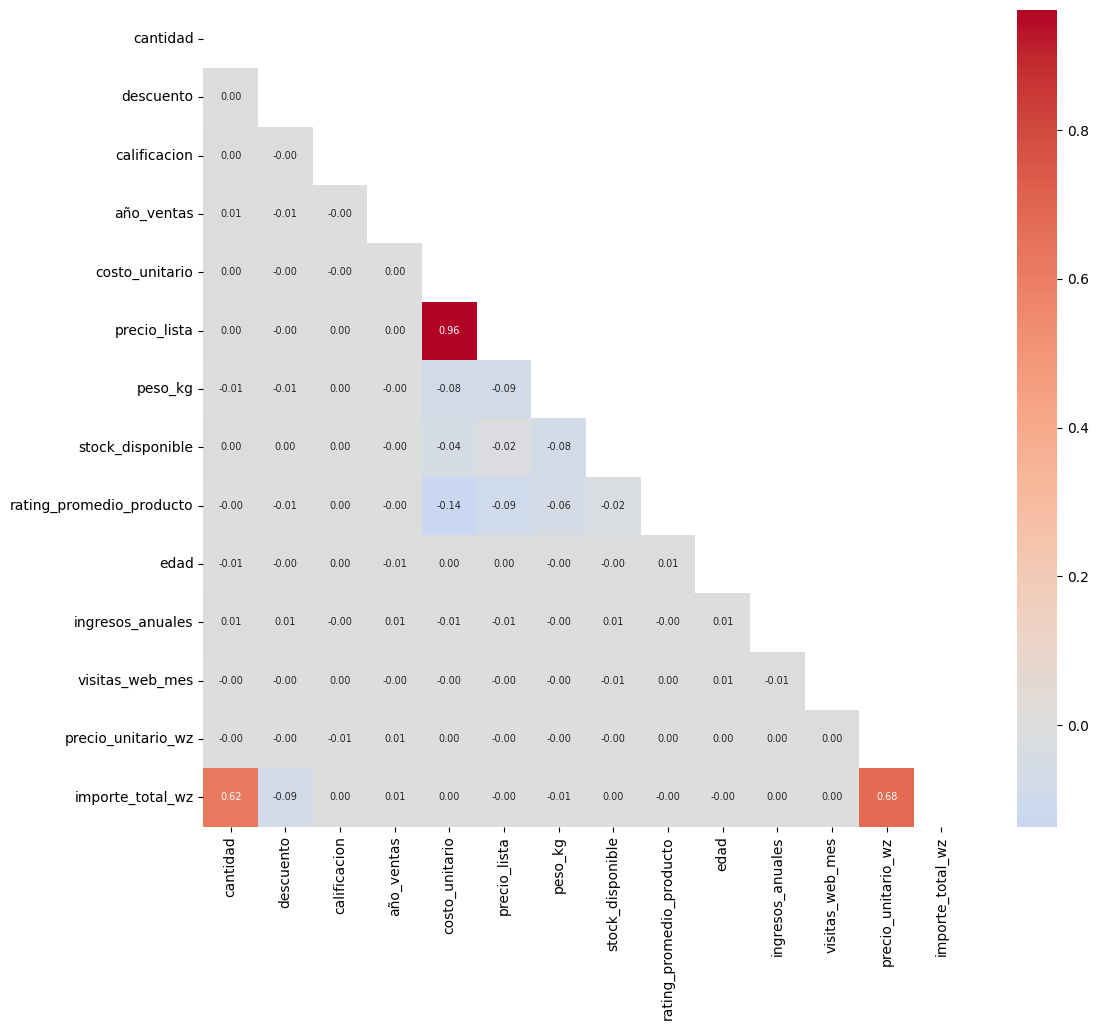

Top 10 pares con mayor correlación (valor absoluto):
precio_lista        costo_unitario              0.961611
precio_unitario_wz  importe_total_wz            0.683578
importe_total_wz    cantidad                    0.618761
costo_unitario      rating_promedio_producto    0.136386
precio_lista        rating_promedio_producto    0.093282
                    peso_kg                     0.087473
importe_total_wz    descuento                   0.086038
costo_unitario      peso_kg                     0.083239
stock_disponible    peso_kg                     0.078744
peso_kg             rating_promedio_producto    0.060227
dtype: float64


,cantidad,descuento,calificacion,año_ventas,costo_unitario,precio_lista,peso_kg,stock_disponible,rating_promedio_producto,edad,ingresos_anuales,visitas_web_mes,precio_unitario_wz,importe_total_wz
cantidad,1.000000,0.000781,0.002524,0.007175,0.002186,0.002015,-0.006401,0.002683,-0.002295,-0.005461,0.008265,-0.001272,-0.001464,0.618761
descuento,0.000781,1.000000,-0.002678,-0.006628,-0.004338,-0.002499,-0.008505,0.000552,-0.007324,-0.000938,0.009475,-0.000737,-0.000098,-0.086038
calificacion,0.002524,-0.002678,1.000000,-0.001121,-0.000729,0.000692,0.004128,0.002129,0.003018,0.004603,-0.003231,0.002079,-0.005543,0.000939
año_ventas,0.007175,-0.006628,-0.001121,1.000000,0.000101,0.000343,-0.004102,-0.002994,-0.004162,-0.008781,0.005536,-0.002913,0.005062,0.007618
costo_unitario,0.002186,-0.004338,-0.000729,0.000101,1.000000,0.961611,-0.083239,-0.044386,-0.136386,0.004430,-0.005925,-0.003166,0.000271,0.000006
precio_lista,0.002015,-0.002499,0.000692,0.000343,0.961611,1.000000,-0.087473,-0.016748,-0.093282,0.004961,-0.006077,-0.003360,-0.001546,-0.001886
peso_kg,-0.006401,-0.008505,0.004128,-0.004102,-0.083239,-0.087473,1.000000,-0.078744,-0.060227,-0.002048,-0.002061,-0.002150,-0.002454,-0.006885
stock_disponible,0.002683,0.000552,0.002129,-0.002994,-0.044386,-0.016748,-0.078744,1.000000,-0.023955,-0.000673,0.006113,-0.010190,-0.002939,0.000004
rating_promedio_producto,-0.002295,-0.007324,0.003018,-0.004162,-0.136386,-0.093282,-0.060227,-0.023955,1.000000,0.007237,-0.001464,0.001963,0.001921,-0.002012
edad,-0.005461,-0.000938,0.004603,-0.008781,0.004430,0.004961,-0.002048,-0.000673,0.007237,1.000000,0.010654,0.010527,0.002398,-0.002472


In [13]:


se.matriz_correlacion(df_pedidos, cols_excluir=cols_excluir)

**Observación:** <BR>
"La matriz de correlación muestra que las relaciones más fuertes corresponden a variables ligadas por fórmula *precio_lista - costo_unitario (0.961611), precio_unitario_wz - importe_total_wz (0.683578) e importe_total_wz - cantidad (0.618761)*  , sin relación de negocio nueva. El resto de variables —demográficas, de producto y de comportamiento— presentan correlaciones prácticamente nulas entre sí, lo que sugiere que no existen relaciones lineales simples entre ellas."

)         



## **Conclusiones — EDA General**<br>

La distribución de `importe_total_wz` está sesgada a la derecha (media 
104,17€ > mediana 72,52€), concentrándose la mayoría de pedidos entre 
20€ y 150€. El boxplot confirma esta asimetría y muestra una acumulación 
de valores en el límite superior (~503€), que no son outliers reales 
sino un artefacto del winsorizing aplicado en la fase de limpieza.

En cuanto a variables categóricas, `web` es el canal dominante (20.887 
pedidos, ~40% del total), seguido de `app movil`; y `tarjeta de credito` 
es el método de pago más usado (34,55%), con un pequeño porcentaje de 
valores "desconocido" (~1,5%) que se trata como dato faltante.

La matriz de correlación no revela relaciones de negocio relevantes: las 
correlaciones más altas corresponden a variables ligadas por fórmula 
(`costo_unitario`-`precio_lista`: 0,96; `cantidad`-`importe_total_wz`: 
0,62), mientras que el resto de variables numéricas —demográficas, de 
producto y de comportamiento— presentan correlaciones prácticamente 
nulas entre sí, lo que anticipa que el comportamiento de compra no se 
explica por relaciones lineales simples entre estas variables.

## FASE 3.2 — CLIENTES

**Objetivo:** construir una tabla a nivel cliente y responder quién compra 
más, quién gasta más y cómo es el ticket medio.

### Construcción de la tabla clientes

In [14]:
clientes = df.groupby('id_cliente').agg(
    n_pedidos=('order_id', 'count'),
    gasto_total=('importe_total_wz', 'sum'),
    edad=('edad', 'first'),
    ciudad=('ciudad', 'first'),
    segmento_cliente=('segmento_cliente', 'first'),
    ).reset_index()

clientes["ticket_medio"] = (
    clientes["gasto_total"] / clientes["n_pedidos"]
)

clientes.head().T

,0,1,2,3,4
id_cliente,00047a8c-eaed-4e09-a302-4081b07e37f9,0005530b-bb59-4862-9ed1-9ba4b57e4b95,000c848f-a5fc-40a5-a3ba-3de5a7e12089,0013343e-3a60-417d-bad5-88780f5a83a1,0030dae9-1d2a-4aaf-ba17-c19d34228fbc
n_pedidos,6,8,1,4,3
gasto_total,582.25,714.03,9.49,520.32,193.17
edad,44.0,64.0,40.0,34.0,48.0
ciudad,barcelona,granada,sevilla,murcia,vigo
segmento_cliente,corporativo,recurrente,nuevo,corporativo,recurrente
ticket_medio,97.041667,89.25375,9.49,130.08,64.39


In [15]:
clientes.describe(include='all')

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ticket_medio
count,7987,7987.000000,7987.000000,7987.000000,7987,7987,7987.000000
unique,7987,NaN,NaN,NaN,10,4,NaN
top,00047a8c-eaed-4e09-a302-4081b07e37f9,NaN,NaN,NaN,bilbao,recurrente,NaN
freq,1,NaN,NaN,NaN,853,3192,NaN
mean,NaN,6.510580,678.175472,40.176161,NaN,NaN,104.102220
std,NaN,2.548941,361.631105,12.124682,NaN,NaN,41.584604
min,NaN,1.000000,9.490000,18.000000,NaN,NaN,9.490000
25%,NaN,5.000000,411.250000,32.000000,NaN,NaN,75.109286
50%,NaN,6.000000,625.640000,40.000000,NaN,NaN,98.173571
75%,NaN,8.000000,890.565450,48.000000,NaN,NaN,125.441250


### Top clientes 
Analisis de gasto_total

In [16]:
top_gasto = clientes.sort_values("gasto_total", ascending=False).head()
top_gasto

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ticket_medio
2344,4bcbfc08-e5f3-49b1-99ab-fb6b41e246f7,17,2746.4800,32.0,valencia,recurrente,161.557647
6376,cc2cdd2c-8ee9-4259-bf1d-5807141b6c20,10,2322.6009,42.0,sevilla,nuevo,232.260090
733,17662b76-6733-4fb1-980f-3718fd98d30e,13,2318.2009,38.0,zaragoza,nuevo,178.323146
6203,c60ae92b-73e5-4e3c-9cb5-37eb55961efd,11,2311.4809,51.0,malaga,vip,210.134627
42,014e6aab-8c29-4b0b-b76d-610e75cff044,9,2304.5218,48.0,zaragoza,corporativo,256.057978


**Observación:** <BR>"El segmento_cliente declarado no coincide con el comportamiento de gasto real: el cliente con mayor gasto total está clasificado como 'recurrente' y no como 'vip', y dos de los cinco clientes de mayor gasto figuran como 'nuevo'. Esto sugiere que la etiqueta de segmento no se basa en el gasto acumulado y debería revisarse su criterio de asignación."

### Distribución de gasto_total

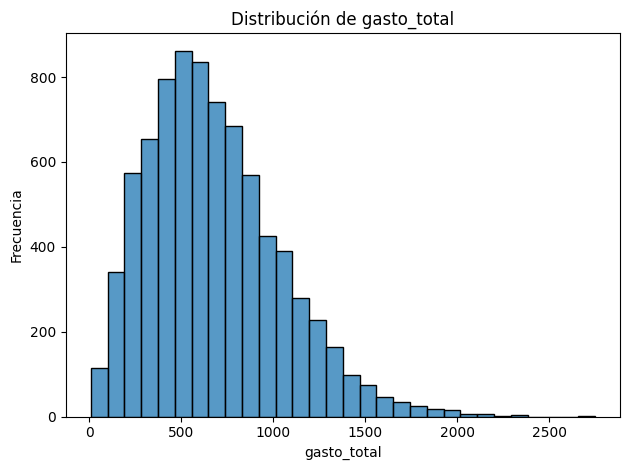

count    7987.00
mean      678.18
std       361.63
min         9.49
25%       411.25
50%       625.64
75%       890.57
max      2746.48
Name: gasto_total, dtype: float64
........................................


In [17]:
se.histplot(clientes, "gasto_total")

Histograma gasto_total

Clara asimetría positiva: el grueso de clientes gasta entre 300€ y 1.000€, con el pico sobre los 500-600€, y una cola larga que se extiende hasta ~2.700€ con muy pocos clientes ahí. Es la forma típica de gasto acumulado (unos pocos compran mucho, la mayoría compra moderado) — nada anómalo, es coherente con lo que ya viste en el histograma de importe_total_wz a nivel pedido.

### n_pedidos

In [18]:
top_freq = clientes.sort_values("n_pedidos", ascending=False).head()
top_freq

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ticket_medio
7771,f9d54acf-ff02-4eda-a470-4e10a762f16a,20,1182.86,44.0,madrid,recurrente,59.143000
2193,47087e3e-a67b-4354-9bd8-1ecb5b2a653c,18,1327.41,72.0,bilbao,nuevo,73.745000
6402,cd1c7936-b0af-45b4-9903-37685d990d8f,18,1521.46,42.0,valencia,corporativo,84.525556
2344,4bcbfc08-e5f3-49b1-99ab-fb6b41e246f7,17,2746.48,32.0,valencia,recurrente,161.557647
7005,dfa29b4e-02c3-4bc8-b327-333bbab375f9,17,1763.90,55.0,barcelona,vip,103.758824


**Observación:** <br>
"La frecuencia de compra y el gasto total no siempre van de la mano: existen clientes con muchos pedidos pero ticket bajo, y clientes con pocos pedidos pero ticket alto que acumulan más gasto total. Además, se detectan de nuevo inconsistencias en segmento_cliente (clientes con 17-18 pedidos etiquetados como 'nuevo'), reforzando la sospecha de que esta variable no refleja el comportamiento real."


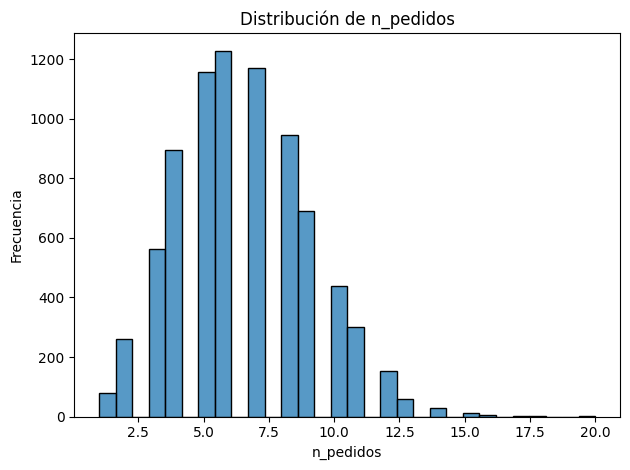

count    7987.00
mean        6.51
std         2.55
min         1.00
25%         5.00
50%         6.00
75%         8.00
max        20.00
Name: n_pedidos, dtype: float64
........................................


In [19]:
se.histplot(clientes, "n_pedidos")

**Observación:** <br>
Distribución razonablemente simétrica (casi normal, ligero sesgo a la derecha), centrada entre 4 y 9 pedidos, con pico en torno a 5-6. Muy pocos clientes superan los 15 pedidos. Nada anómalo — comportamiento esperable de frecuencia de compra.

### Ticket medio

In [20]:
clientes["ticket_medio"].describe()

count    7987.000000
mean      104.102220
std        41.584604
min         9.490000
25%        75.109286
50%        98.173571
75%       125.441250
max       503.060900
Name: ticket_medio, dtype: float64

**Observación:** <br> "El ticket medio por cliente se sitúa mayoritariamente entre 75€ y 125€ (mediana 98€), con una distribución asimétrica hacia valores altos. El máximo observado (503€) coincide con el límite superior aplicado en el winsorizing de importe_total, por lo que debe interpretarse con cautela y no como un comportamiento de compra extremo real."

### Segmento y ciudad (ajuste que añadimos)

In [21]:
clientes.groupby("segmento_cliente")["gasto_total"].mean().round(2)

segmento_cliente
corporativo    687.29
nuevo          678.27
recurrente     671.94
vip            688.73
Name: gasto_total, dtype: float64

In [22]:
clientes.groupby("ciudad")["gasto_total"].sum().sort_values(ascending=False)

ciudad
malaga       586433.5485
bilbao       579816.1241
granada      566962.9705
barcelona    548528.6577
madrid       543265.6705
sevilla      540877.3096
valencia     537715.4277
murcia       524622.4149
zaragoza     503323.2959
vigo         485042.0786
Name: gasto_total, dtype: float64

In [23]:
clientes.groupby("ciudad").agg(
    gasto_total=("gasto_total", "sum"),
    gasto_medio=("gasto_total", "mean"),
    n_clientes=("id_cliente", "count")
).sort_values("gasto_total", ascending=False)

,gasto_total,gasto_medio,n_clientes
ciudad,,,
malaga,586433.5485,697.305052,841
bilbao,579816.1241,679.737543,853
granada,566962.9705,672.553939,843
barcelona,548528.6577,661.675100,829
madrid,543265.6705,694.713134,782
sevilla,540877.3096,676.096637,800
valencia,537715.4277,676.371607,795
murcia,524622.4149,676.059813,776
zaragoza,503323.2959,670.204122,751


### **Conclusiones — Clientes**

- **Concentración de gasto:** la distribución de gasto_total está sesgada 
  a la derecha; la mayoría de clientes gasta entre 300€ y 1.000€, con una 
  cola de clientes de alto valor que se extiende hasta ~2.700€.

- **Frecuencia vs valor:** n_pedidos y gasto_total no siempre van juntos. 
  Existen clientes de alta frecuencia y ticket bajo, y clientes de baja 
  frecuencia con ticket alto que acumulan más gasto total. El ticket medio 
  se concentra entre 75€ y 125€ (mediana 98€), con el máximo (503€) 
  probablemente afectado por el límite del winsorizing y no por un 
  comportamiento real.

- **segmento_cliente no refleja el comportamiento real:** el gasto medio 
  apenas varía entre segmentos (671€-689€), y casos concretos lo confirman 
  (el cliente de mayor gasto está etiquetado "recurrente", no "vip"; hay 
  clientes "nuevo" con 17-18 pedidos). La etiqueta debería revisarse.

- **ciudad tampoco diferencia el gasto:** el gasto medio por ciudad es 
  prácticamente constante (661€-697€); las diferencias en gasto total 
  se explican por el número de clientes por ciudad, no por mayor gasto 
  individual.

## FASE 3.3 — PRODUCTOS

**Objetivo:** analizar qué productos, categorías y marcas generan más 
ventas, y si hay diferencias reales de margen entre ellos.

In [24]:
productos = (
    df_pedidos.groupby("product_id")
      .agg(
          ventas=("importe_total_wz", "sum"),
          unidades=("cantidad", "sum"),
          pedidos=("order_id", "nunique"),
          precio_medio=("precio_unitario", "mean"),
          costo_medio=("costo_unitario", "mean"),
          categoria=("categoria_producto", "first"),
          marca=("marca", "first"),
          rating=("rating_promedio_producto", "first")
      )
      .reset_index()
)

productos["margen"] = productos["precio_medio"] - productos["costo_medio"]
productos.head()

,product_id,ventas,unidades,pedidos,precio_medio,costo_medio,categoria,marca,rating,margen
0,P0001,56705.7036,1133,553,54.615081,26.73,electronica,urbanix,3.60,27.885081
1,P0002,58341.8027,1157,594,54.967677,47.97,electronica,urbanix,3.29,6.997677
2,P0003,68095.0881,1352,678,54.690767,49.49,electronica,nova,4.18,5.200767
3,P0004,65146.6690,1227,601,61.814875,60.57,electronica,norte&co,2.94,1.244875
4,P0005,63344.3454,1203,597,56.234874,17.49,electronica,zentra,3.95,38.744874


### Top productos por ventas

In [25]:
top_ventas = productos.sort_values("ventas", ascending=False).head(5)
top_ventas

,product_id,ventas,unidades,pedidos,precio_medio,costo_medio,categoria,marca,rating,margen
2,P0003,68095.0881,1352,678,54.690767,49.49,electronica,nova,4.18,5.200767
75,P0076,67576.2763,1301,631,60.438700,39.69,libros,prisma,4.07,20.748700
82,P0083,66828.8490,1246,621,60.235942,9.96,libros,kore,3.52,50.275942
59,P0060,66729.3536,1250,586,61.555751,24.00,deporte,vantia,3.24,37.555751
57,P0058,66613.8490,1293,612,57.279232,49.34,deporte,vantia,3.35,7.939232


### Top productos por unidades vendidas

In [26]:
top_unidades = productos.sort_values("unidades", ascending=False).head(5)
top_unidades

,product_id,ventas,unidades,pedidos,precio_medio,costo_medio,categoria,marca,rating,margen
2,P0003,68095.0881,1352,678,54.690767,49.49,electronica,nova,4.18,5.200767
75,P0076,67576.2763,1301,631,60.438700,39.69,libros,prisma,4.07,20.748700
9,P0010,63917.8754,1299,611,54.612029,23.59,electronica,lumen,2.89,31.022029
57,P0058,66613.8490,1293,612,57.279232,49.34,deporte,vantia,3.35,7.939232
62,P0063,63768.0263,1273,618,56.559191,34.26,deporte,zentra,4.84,22.299191


**Observación:** <br> "Los productos más vendidos no son homogéneos: algunos generan altas ventas gracias a un gran volumen de unidades con margen bajo (ej. P0003, margen 5,2€), mientras que otros alcanzan ventas similares con muchas menos unidades pero un margen mucho mayor (ej. P0083, margen 50,3€). Esto indica que priorizar solo por ventas en euros puede ocultar diferencias importantes de rentabilidad."

### Ventas por categoría

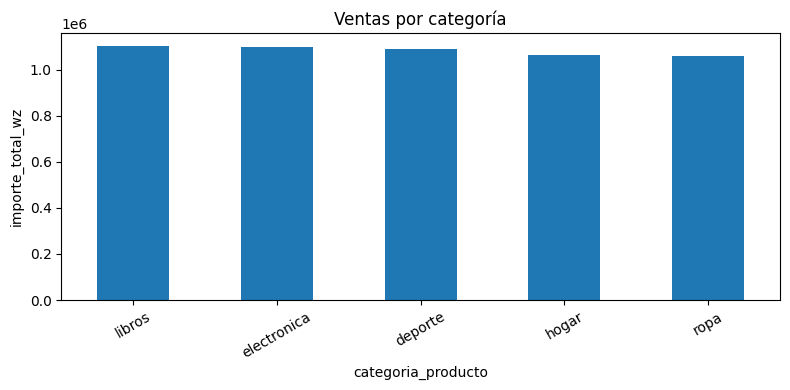

categoria_producto
libros         1104741.23
electronica    1098241.34
deporte        1088910.58
hogar          1065496.77
ropa           1059197.57
Name: importe_total_wz, dtype: float64


categoria_producto
libros         1.104741e+06
electronica    1.098241e+06
deporte        1.088911e+06
hogar          1.065497e+06
ropa           1.059198e+06
Name: importe_total_wz, dtype: float64

In [27]:
ventas_categoria = df_pedidos.groupby("categoria_producto")["importe_total_wz"].sum().sort_values(ascending=False)
se.barplot_serie(ventas_categoria, titulo="Ventas por categoría", kind="bar")

### Ventas por marca

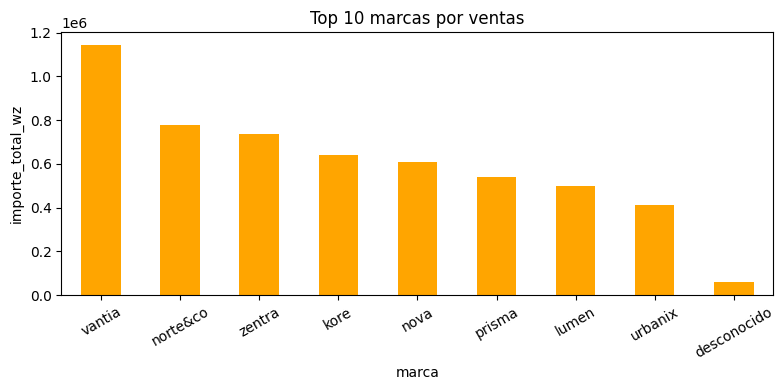

marca
vantia         1144590.62
norte&co        776312.63
zentra          735800.47
kore            641764.20
nova            608383.38
prisma          538322.97
lumen           500602.53
urbanix         410246.94
desconocido      60563.76
Name: importe_total_wz, dtype: float64


marca
vantia         1.144591e+06
norte&co       7.763126e+05
zentra         7.358005e+05
kore           6.417642e+05
nova           6.083834e+05
prisma         5.383230e+05
lumen          5.006025e+05
urbanix        4.102469e+05
desconocido    6.056376e+04
Name: importe_total_wz, dtype: float64

In [28]:
ventas_marca = df_pedidos.groupby("marca")["importe_total_wz"].sum().sort_values(ascending=False)
se.barplot_serie(ventas_marca.head(10), titulo="Top 10 marcas por ventas", kind="bar", color="orange")

**Observación:** <br>
"A diferencia de categoria_producto (que apenas diferencia ventas entre sus 5 valores), la marca sí muestra diferencias claras: vantia lidera con un volumen de ventas significativamente superior al resto (~3x frente a las marcas más bajas). El valor 'desconocido' representa una minoría de registros sin marca informada, no una marca de bajo rendimiento."

### Margen por categoría

In [29]:
productos.groupby("categoria")["margen"].mean().round(2).sort_values(ascending=False)

categoria
hogar          29.29
ropa           26.33
libros         25.67
deporte        24.72
electronica    14.72
Name: margen, dtype: float64

**Observación:** <br>"Aunque las 5 categorías generan ventas muy similares en euros, el margen medio varía notablemente: hogar lidera con 29,29€, mientras que electrónica cae a 14,72€, casi la mitad. Esto confirma a nivel categoría lo observado a nivel producto individual (P0003): electrónica aporta volumen de ventas comparable al resto, pero con menor rentabilidad. Un análisis basado solo en ventas habría ocultado esta diferencia."

### Conclusiones — Productos

- **Ventas vs. rotación:** algunos productos venden mucho gracias a alto 
  volumen y margen bajo (P0003), otros alcanzan ventas similares con menos 
  unidades pero margen mucho mayor (P0083). "Vender mucho" y "ser rentable" 
  no son lo mismo en este dataset.

- **Categoría no diferencia ventas:** las 5 categorías generan un volumen 
  de ventas muy similar (~1,06M-1,10M), a diferencia de segmento_cliente 
  y ciudad, que tampoco diferenciaban comportamiento de cliente.

- **Marca sí diferencia ventas:** vantia lidera claramente (~1,14M), casi 
  3x por encima de las marcas más bajas del top 10. 'desconocido' 
  representa registros sin marca informada, no bajo rendimiento real.

- **Margen revela lo que ventas oculta:** pese a vender de forma similar, 
  electrónica tiene el margen medio más bajo (14,72€) frente a hogar 
  (29,29€, el más alto). Analizar solo ventas habría ocultado esta 
  diferencia de rentabilidad entre categorías.

## FASE 3.4 — CANALES Y OPERACIONES

**Objetivo:** entender cómo compran los clientes (canal, método de pago), 
si el envío gratis influye en el importe, y qué explica (o no) la 
devolución de pedidos.

### Ventas por canal

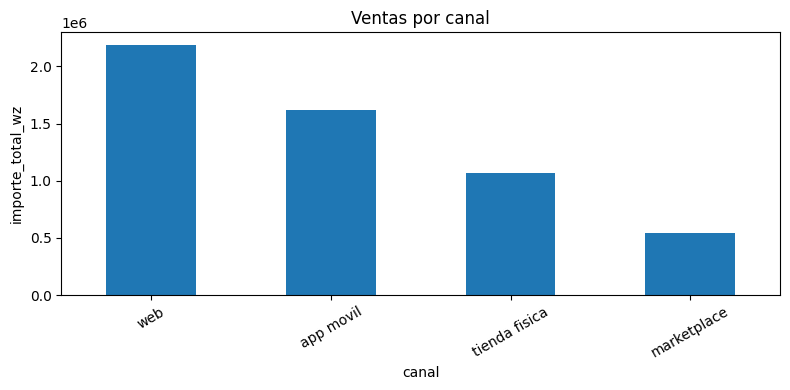

canal
web              2188296.01
app movil        1617170.69
tienda fisica    1064601.15
marketplace       546519.64
Name: importe_total_wz, dtype: float64


canal
web              2.188296e+06
app movil        1.617171e+06
tienda fisica    1.064601e+06
marketplace      5.465196e+05
Name: importe_total_wz, dtype: float64

In [30]:
ventas_canal = df_pedidos.groupby("canal")["importe_total_wz"].sum().sort_values(ascending=False)
se.barplot_serie(ventas_canal, titulo="Ventas por canal", kind="bar")

**Observación:** <br>
Web (2,19M) → app móvil (1,62M) → tienda física (1,06M) → marketplace (0,55M). Mismo ranking que ya viste en número de pedidos en Fase 1 (web 20.887 → app 15.498 → tienda 10.380 → marketplace 5.235). Es un resultado esperable: no hay sorpresa aquí, el canal que más vende en euros es el mismo que más pedidos genera, en proporciones similares. Confírmalo con una frase corta, no hace falta mucho más.


### Ticket medio por canal

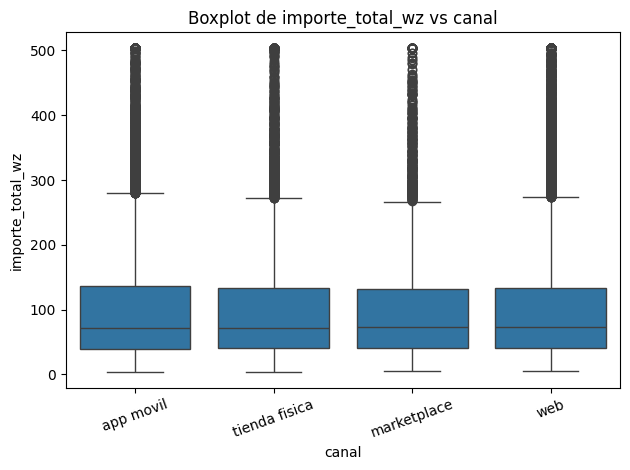

Resumen de importe_total_wz por canal:
                 count    mean    std   min    25%    50%     75%     max
canal                                                                    
app movil      15498.0  104.35  95.87  4.22  39.65  71.79  135.77  503.06
marketplace     5235.0  104.40  95.35  4.71  40.33  73.79  131.30  503.06
tienda fisica  10380.0  102.56  92.90  4.40  40.04  71.96  132.95  503.06
web            20887.0  104.77  95.67  4.63  40.23  73.14  133.86  503.06


,count,mean,std,min,25%,50%,75%,max
canal,,,,,,,,
app movil,15498.0,104.35,95.87,4.22,39.65,71.79,135.77,503.06
marketplace,5235.0,104.40,95.35,4.71,40.33,73.79,131.30,503.06
tienda fisica,10380.0,102.56,92.90,4.40,40.04,71.96,132.95,503.06
web,20887.0,104.77,95.67,4.63,40.23,73.14,133.86,503.06


In [31]:
se.boxplot_bivar(df_pedidos, col_cat="canal", col_num="importe_total_wz")

**Observación:** <br>
Aquí está lo interesante, y es el mismo patrón que ya te has acostumbrado a detectar: mirando la tabla resumen, la mediana apenas varía entre canales — 71,79€ (app), 73,79€ (marketplace), 71,96€ (tienda), 73,14€ (web). Rango de menos de 2€. Lo mismo con la media (102,56€-104,77€).

Esto significa que web vende más simplemente porque tiene más pedidos, no porque cada compra en web sea mayor. El canal no influye en cuánto gasta el cliente por pedido, solo en cuántos pedidos entran por ese canal. Es exactamente el mismo tipo de conclusión que sacaste con ciudad en Fase 2 (más clientes, no más gasto individual).

Detalle técnico a anotar: el máximo es 503,06€ en los 4 canales, sin excepción — otra vez el límite del winsorizing, no un patrón real. Ya lo tienes identificado, solo hay que mencionarlo si comentas los outliers del boxplot.

**Conclusión:**

"Web genera más facturación en valor absoluto, pero esto se explica por su mayor volumen de pedidos, no por un ticket medio superior: la mediana de importe_total_wz es prácticamente idéntica entre los 4 canales (71-74€). El canal de compra no influye en cuánto gasta el cliente por pedido, solo en el volumen total de operaciones que genera."

### Método de pago preferido

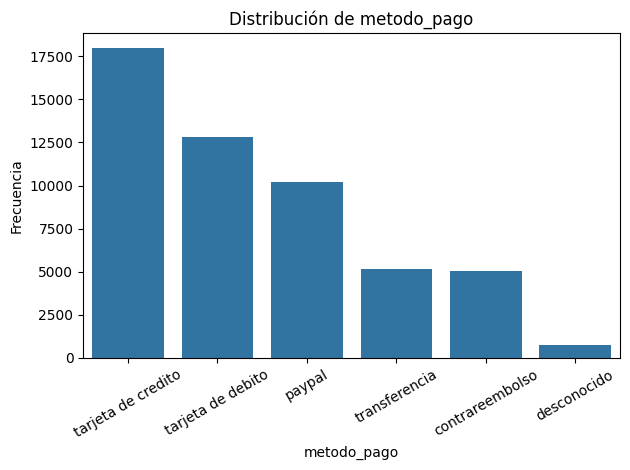

metodo_pago
tarjeta de credito    17964
tarjeta de debito     12825
paypal                10219
transferencia          5181
contrareembolso        5031
desconocido             780
Name: count, dtype: int64
........................................
PORCENTAJES
metodo_pago
tarjeta de credito    34.55
tarjeta de debito     24.66
paypal                19.65
transferencia          9.96
contrareembolso        9.68
desconocido            1.50
Name: proportion, dtype: float64


In [32]:
se.countplot(df_pedidos, "metodo_pago")

**Observación:** <br> Confirma lo que ya sabías desde Fase 1: tarjeta de crédito domina (34,55%), seguida de débito (24,66%) y PayPal (19,65%). Transferencia y contrareembolso están casi empatados (~10% cada uno). desconocido queda en 1,50% — recuerda mencionarlo como limitación del dato, no como método real. Nada nuevo aquí, solo confirmación visual de Fase 1.

### Envío gratis vs importe

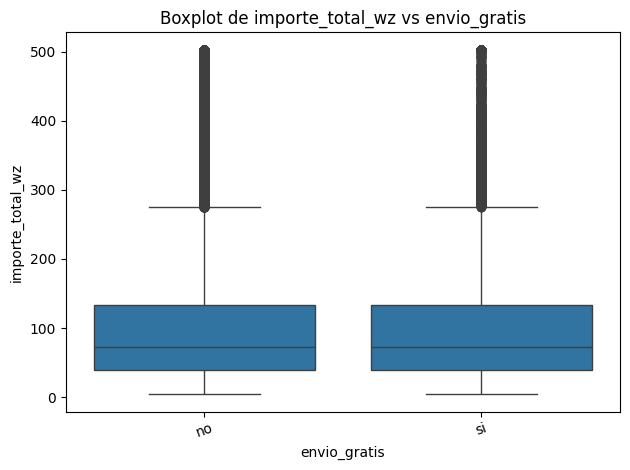

Resumen de importe_total_wz por envio_gratis:
                count    mean    std   min    25%    50%     75%     max
envio_gratis                                                            
no            36333.0  104.23  95.26  4.22  40.05  72.49  133.88  503.06
si            15667.0  104.02  94.91  4.62  39.94  72.60  134.08  503.06


,count,mean,std,min,25%,50%,75%,max
envio_gratis,,,,,,,,
no,36333.0,104.23,95.26,4.22,40.05,72.49,133.88,503.06
si,15667.0,104.02,94.91,4.62,39.94,72.60,134.08,503.06


In [33]:
se.boxplot_bivar(df_pedidos, col_cat="envio_gratis", col_num="importe_total_wz")

**Observación:** <br>
El guion original preguntaba "¿el envío gratis se asocia con un mayor importe?", esperando que sí (razonamiento típico: el envío gratis suele activarse a partir de un umbral de compra). Pero los datos dicen que no hay diferencia:

Mediana: 72,49€ (sin envío gratis) vs 72,60€ (con envío gratis) — prácticamente idéntico.
Media: 104,23€ vs 104,02€ — igual de plano.
El boxplot es visualmente indistinguible entre ambos grupos.

Esto es importante decirlo así, tal cual: es un hallazgo, no un fallo del análisis. En este dataset, envio_gratis no depende del importe de la compra — probablemente se asigna por otro criterio (tipo de producto, promoción puntual, tipo de cliente...) en vez de por un umbral mínimo de gasto, como suele ser habitual en e-commerce real.


conclusión:

"A diferencia de lo esperado, el envío gratis no está asociado a un mayor importe de compra: la distribución de importe_total_wz es prácticamente idéntica con o sin envío gratis (mediana ~72,5€ en ambos casos). Esto sugiere que en este dataset el envío gratis no se activa por un umbral de gasto, sino que responde a otro criterio no capturado en los datos disponibles.

#### Tasa de devolución global

In [34]:
tasa_devolucion_global = (df_pedidos["devuelto"] == "si").mean() * 100
print(f"Tasa de devolución global: {tasa_devolucion_global:.2f}%")

Tasa de devolución global: 5.88%


#### Devolución por canal 

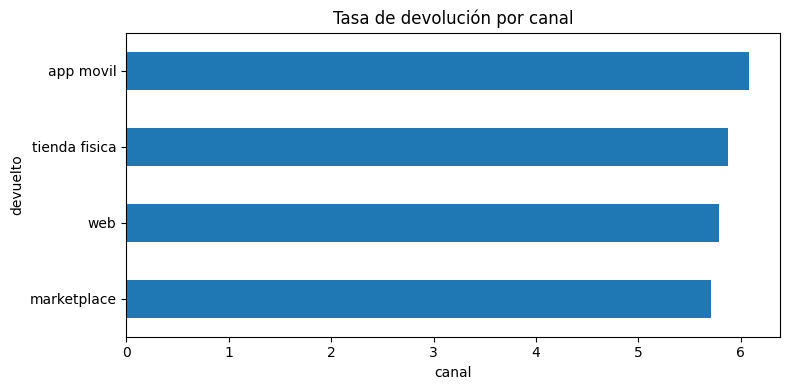

canal
marketplace      5.71
web              5.78
tienda fisica    5.88
app movil        6.08
Name: devuelto, dtype: float64


canal
marketplace      5.711557
web              5.783502
tienda fisica    5.876686
app movil        6.078204
Name: devuelto, dtype: float64

In [35]:
devol_canal = df_pedidos.groupby("canal")["devuelto"].apply(lambda x: (x == "si").mean() * 100)
se.barplot_serie(devol_canal.sort_values(), titulo="Tasa de devolución por canal", kind="barh")

#### Devolución por método de pago (pendiente de cerrar)

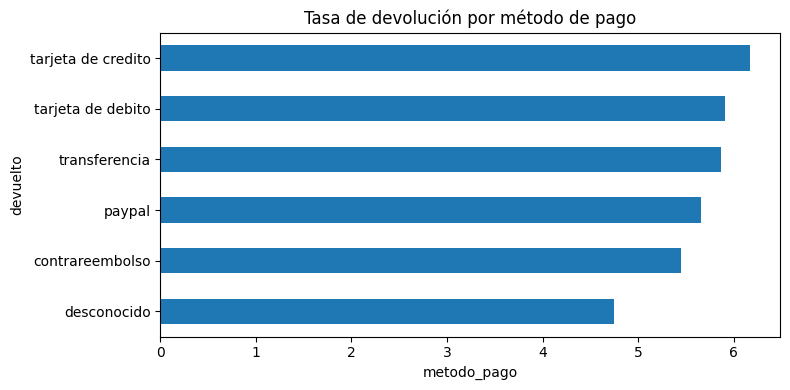

metodo_pago
desconocido           4.74
contrareembolso       5.45
paypal                5.66
transferencia         5.87
tarjeta de debito     5.90
tarjeta de credito    6.17
Name: devuelto, dtype: float64


metodo_pago
desconocido           4.743590
contrareembolso       5.446233
paypal                5.656131
transferencia         5.867593
tarjeta de debito     5.902534
tarjeta de credito    6.173458
Name: devuelto, dtype: float64

In [36]:
devol_pago = df_pedidos.groupby("metodo_pago")["devuelto"].apply(lambda x: (x == "si").mean() * 100)
se.barplot_serie(devol_pago.sort_values(), titulo="Tasa de devolución por método de pago", kind="barh")

### Devolución por envío gratis (pendiente de cerrar)

In [37]:
devol_envio = df_pedidos.groupby("envio_gratis")["devuelto"].apply(lambda x: (x == "si").mean() * 100)
devol_envio

envio_gratis
no    5.931247
si    5.770090
Name: devuelto, dtype: float64

**Observación:** <br>
"La tasa de devolución (5,88% global) es prácticamente idéntica en todas las variables categóricas analizadas: categoría de producto (5,66%-6,06%), canal (5,71%-6,08%), método de pago (4,74%-6,17%, siendo el valor más bajo un dato faltante) y envío gratis (5,77%-5,93%). Con los datos disponibles, la devolución no puede explicarse por el comportamiento de compra ni por el canal u operativa utilizada; es probable que dependa de factores no capturados en este dataset (calidad física del producto, motivo declarado por el cliente, etc.)."

### Conclusiones — Canales y Operaciones

- **Web lidera en volumen, no en ticket:** genera más facturación (2,19M€) 
  por tener más pedidos, no porque cada compra sea mayor — el ticket 
  mediano es casi idéntico entre los 4 canales (71-74€).

- **Tarjeta de crédito es el método dominante** (34,55%), seguido de 
  débito y PayPal. "Desconocido" (1,5%) es dato faltante, no un método real.

- **Envío gratis no está ligado al importe** (contrario a lo esperado): 
  la mediana de importe es prácticamente igual con o sin envío gratis. 
  Sugiere que se asigna por otro criterio, no por umbral de gasto.

- **La devolución es independiente de categoría, canal, método de pago y 
  envío gratis** — la tasa se mantiene entre 4,7% y 6,2% en todos los 
  casos, sin ninguna variable que la explique con claridad.

## FASE 3.5 — ANÁLISIS TEMPORAL

**Objetivo:** entender cuándo se generan las ventas, distinguiendo la 
tendencia general (por año) de la estacionalidad (por mes).

### Preparación de variables temporales

In [38]:
df_pedidos["mes_ventas"] = df_pedidos["fecha_pedido"].dt.month

In [39]:
(df_pedidos["fecha_pedido"].dt.year == df_pedidos["año_ventas"]).all()

np.True_

### Ventas por año (tendencia del negocio)

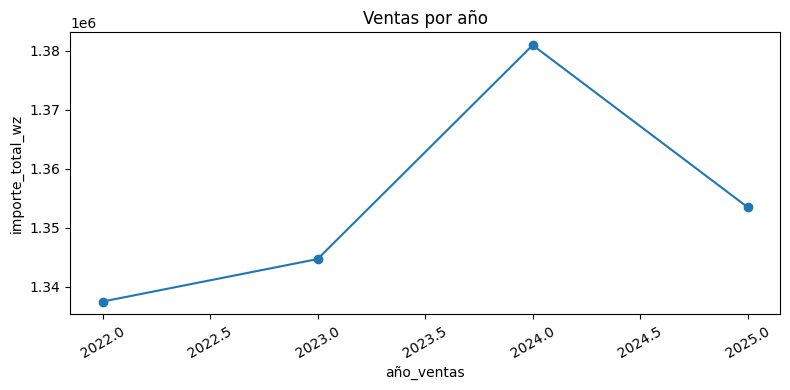

año_ventas
2022    1337468.30
2023    1344682.73
2024    1380971.21
2025    1353465.26
Name: importe_total_wz, dtype: float64


año_ventas
2022    1.337468e+06
2023    1.344683e+06
2024    1.380971e+06
2025    1.353465e+06
Name: importe_total_wz, dtype: float64

In [40]:
ventas_año = df_pedidos.groupby("año_ventas")["importe_total_wz"].sum()
se.barplot_serie(ventas_año, titulo="Ventas por año", kind="line")

**Observación:** "Las ventas se mantienen relativamente estables entre 2022 y 2025 (variación total de solo un 3,2% entre el año más bajo y el más alto), con un ligero pico en 2024. No se observa una tendencia clara de crecimiento ni decrecimiento del negocio en el periodo analizado. Nota: el gráfico de líneas puede parecer más pronunciado de lo real porque el eje Y no comienza en cero."

### Ventas por mes (estacionalidad, todos los años combinados)

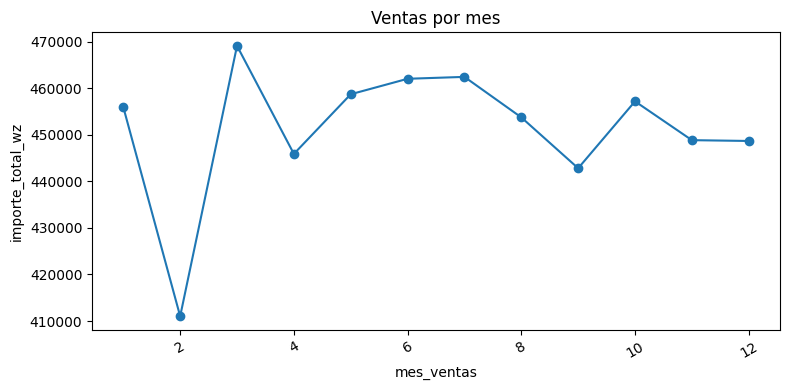

mes_ventas
1     455953.75
2     411025.01
3     469124.36
4     445910.18
5     458726.62
6     462050.07
7     462458.17
8     453757.06
9     442830.73
10    457201.55
11    448862.21
12    448687.80
Name: importe_total_wz, dtype: float64


mes_ventas
1     455953.7532
2     411025.0070
3     469124.3559
4     445910.1759
5     458726.6223
6     462050.0714
7     462458.1669
8     453757.0641
9     442830.7260
10    457201.5460
11    448862.2060
12    448687.8033
Name: importe_total_wz, dtype: float64

In [41]:
ventas_mes = df_pedidos.groupby("mes_ventas")["importe_total_wz"].sum()
se.barplot_serie(ventas_mes, titulo="Ventas por mes", kind="line")

**Observación:**<br> "Se observa un patrón estacional moderado: febrero es sistemáticamente el mes más débil (411k€) y marzo el más fuerte (469k€), con una diferencia de ~13% entre ambos. El resto de meses se mantiene en una banda estable (443k-462k€), sin picos marcados en periodos que suelen ser fuertes en retail (campañas navideñas, rebajas de verano), lo que sugiere que las ventas no están fuertemente influidas por estacionalidad comercial típica."

### Pedidos por mes

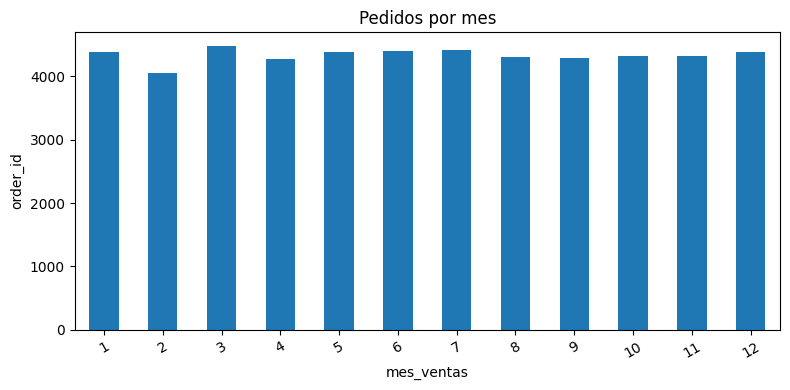

mes_ventas
1     4384
2     4056
3     4473
4     4269
5     4383
6     4401
7     4411
8     4302
9     4295
10    4321
11    4319
12    4386
Name: order_id, dtype: int64


mes_ventas
1     4384
2     4056
3     4473
4     4269
5     4383
6     4401
7     4411
8     4302
9     4295
10    4321
11    4319
12    4386
Name: order_id, dtype: int64

In [42]:
pedidos_mes = df_pedidos.groupby("mes_ventas")["order_id"].nunique()
se.barplot_serie(pedidos_mes, titulo="Pedidos por mes", kind="bar")

**Observación:**<br> "La estacionalidad detectada en ventas coincide exactamente con la del número de pedidos: febrero es el mes con menos pedidos (4.056) y ventas más bajas, marzo el de más pedidos (4.473) y ventas más altas. Esto indica que las variaciones mensuales en ventas se deben al volumen de pedidos, no a cambios en el importe medio por compra."

### Ticket medio por mes

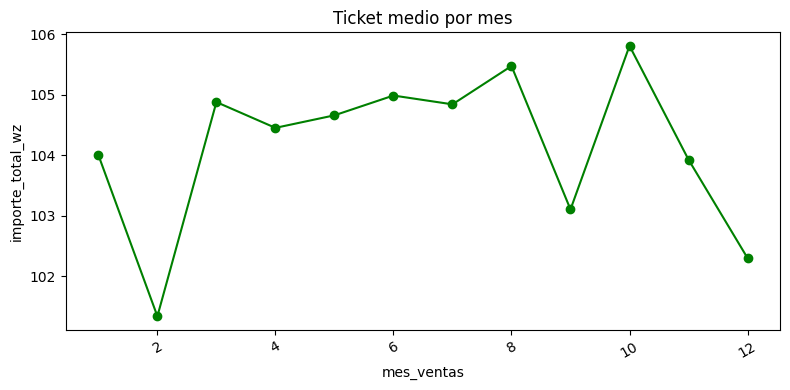

mes_ventas
1     104.00
2     101.34
3     104.88
4     104.45
5     104.66
6     104.99
7     104.84
8     105.48
9     103.10
10    105.81
11    103.93
12    102.30
Name: importe_total_wz, dtype: float64


mes_ventas
1     104.004050
2     101.337526
3     104.879132
4     104.453075
5     104.660420
6     104.987519
7     104.842024
8     105.475840
9     103.103778
10    105.809198
11    103.927346
12    102.300001
Name: importe_total_wz, dtype: float64

In [43]:
ticket_mes = df_pedidos.groupby("mes_ventas")["importe_total_wz"].mean()
se.barplot_serie(ticket_mes, titulo="Ticket medio por mes", kind="line", color="green")

**Observación:**<br> "El ticket medio mensual se mantiene estable (101-106€, variación de solo ~4%), confirmando que el factor dominante detrás de la estacionalidad de ventas es el volumen de pedidos, no el importe medio por compra. Febrero combina el menor número de pedidos con el ticket más bajo, lo que explica que sea el mes más débil del año."

### Devoluciones por mes

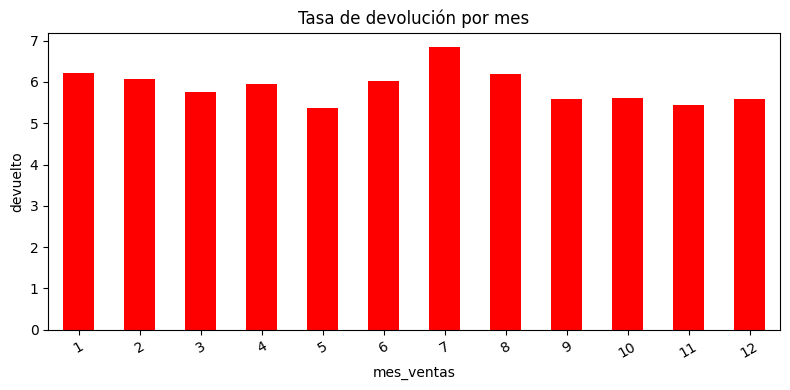

mes_ventas
1     6.20
2     6.07
3     5.75
4     5.95
5     5.36
6     6.02
7     6.85
8     6.18
9     5.59
10    5.60
11    5.44
12    5.59
Name: devuelto, dtype: float64


mes_ventas
1     6.204380
2     6.065089
3     5.745585
4     5.949871
5     5.361624
6     6.021359
7     6.846520
8     6.183171
9     5.587893
10    5.600555
11    5.441074
12    5.585955
Name: devuelto, dtype: float64

In [44]:
devol_mes = df_pedidos.groupby("mes_ventas")["devuelto"].apply(lambda x: (x == "si").mean() * 100)
se.barplot_serie(devol_mes, titulo="Tasa de devolución por mes", kind="bar", color="red")

**Observación:**<br> "La tasa de devolución mensual oscila entre 5,36% y 6,85%, sin un patrón estacional claro. Julio destaca como el mes con mayor devolución, pero no coincide con los meses de mayor volumen de ventas o pedidos, por lo que no parece explicarse por estacionalidad de la demanda. Esto refuerza la conclusión de Fase 4: la devolución se comporta de forma prácticamente independiente de las variables disponibles en el dataset."

### Conclusiones — Análisis Temporal

- **Tendencia anual estable:** las ventas varían solo un 3,2% entre 2022 
  y 2025, con un ligero pico en 2024. No hay crecimiento ni decrecimiento 
  claro del negocio en el periodo.

- **Estacionalidad moderada, ligada al volumen:** febrero es el mes más 
  débil y marzo el más fuerte (~13% de diferencia), y este patrón viene 
  del número de pedidos, no del ticket medio (que se mantiene estable, 
  101-106€ todo el año).

- **Sin estacionalidad comercial típica:** no se observan picos en 
  periodos habituales de retail (Navidad, rebajas de verano).

- **La devolución no muestra patrón temporal claro** (5,36%-6,85%), 
  consistente con el resto del EDA: no depende de categoría, canal, 
  método de pago, envío gratis ni, ahora, del mes del año.

## FASE 3.6 — CONCLUSIONES FINALES

### 1. Resumen del proyecto

El objetivo de este proyecto ha sido analizar el comportamiento de clientes, 
productos, canales y ventas de un dataset de comercio electrónico (52.000 
pedidos, periodo 2022-2025) mediante técnicas de análisis exploratorio de 
datos (EDA), con el fin de identificar patrones, relaciones entre variables 
y posibles áreas de mejora para el negocio.

### 2. Calidad de los datos

Se partió de un dataset ya limpio en la Fase 2 (02_datos_limpios.csv), 
revisando en la Fase 3 la ausencia de duplicados y confirmando que los 
nulos restantes (por ejemplo en fecha_registro) eran intencionados, 
tratados previamente en la fase de limpieza. También se identificó la 
categoría "desconocido" en variables como metodo_pago y marca como dato 
faltante, no como un valor real, y se tuvo en cuenta al interpretar los 
resultados.

### 3. Hallazgos del EDA general

La mayor parte de los pedidos se concentra en importes moderados 
(importe_total_wz), con una distribución sesgada a la derecha y una cola 
de pedidos de mayor valor. La matriz de correlación mostró que las 
relaciones más fuertes corresponden a variables ligadas por fórmula 
(costo_unitario-precio_lista: 0,96; cantidad-importe_total_wz: 0,62), 
sin relaciones de negocio nuevas. El resto de variables —demográficas, 
de producto y de comportamiento— presentan correlaciones prácticamente 
nulas entre sí.

### 4. Conclusiones sobre clientes

La distribución de gasto_total está sesgada a la derecha, con una cola 
de clientes de alto valor. La frecuencia de compra (n_pedidos) y el gasto 
total no siempre van de la mano: existen clientes de alta frecuencia y 
ticket bajo, y clientes de baja frecuencia con ticket alto que acumulan 
más gasto. Un hallazgo relevante es que segmento_cliente y ciudad no 
diferencian el comportamiento real de gasto (rangos de apenas 17-35€ 
entre categorías), y se detectaron casos concretos que lo confirman 
(el cliente de mayor gasto está etiquetado "recurrente", no "vip"; 
clientes "nuevo" con 17-18 pedidos). Esto sugiere que estas etiquetas 
no reflejan el comportamiento real y su criterio de asignación debería 
revisarse.

### 5. Conclusiones sobre productos

Los productos más vendidos no son homogéneos: algunos generan altas 
ventas gracias a un gran volumen de unidades con margen bajo, mientras 
otros alcanzan ventas similares con menos unidades pero mayor margen. 
A nivel categoría, las ventas en euros son muy similares entre las 5 
categorías (~1,06M-1,10M€), pero el margen medio varía notablemente: 
electrónica presenta el margen más bajo (14,72€) frente a hogar (29,29€, 
el más alto). A nivel marca sí existen diferencias claras en volumen 
de ventas, con vantia liderando de forma notable (~3x las marcas más 
bajas del top 10).

### 6. Conclusiones sobre canales y operaciones

Web genera la mayor facturación, pero por volumen de pedidos, no por 
ticket medio superior: la mediana de importe es prácticamente idéntica 
entre los 4 canales (71-74€). Tarjeta de crédito es el método de pago 
dominante (34,55%). Contrario a lo esperado, el envío gratis no está 
asociado a un mayor importe de compra. La tasa de devolución global 
(5,88%) se mantiene prácticamente constante frente a categoría, canal, 
método de pago y envío gratis, sin que ninguna de estas variables la 
explique con claridad.

### 7. Conclusiones temporales

Las ventas se mantienen relativamente estables entre 2022 y 2025 
(variación de solo un 3,2%), sin tendencia clara de crecimiento o 
decrecimiento. Se observa una estacionalidad moderada: febrero es 
sistemáticamente el mes más débil y marzo el más fuerte, explicada por 
el volumen de pedidos y no por el ticket medio (que se mantiene estable 
todo el año). No se detectan picos en periodos comerciales típicos 
(Navidad, rebajas de verano). La tasa de devolución mensual tampoco 
muestra un patrón estacional claro.

### 8. Limitaciones

El análisis se limita a la información disponible en el dataset y no 
incorpora factores externos como campañas de marketing, competencia o 
eventos puntuales. La devolución, en particular, no puede explicarse 
con las variables disponibles, lo que sugiere que su causa depende de 
factores no capturados (motivo declarado, calidad física del producto, 
experiencia postventa, etc.). Además, algunas variables presentan un 
porcentaje pequeño de valores no informados ("desconocido"), que se 
excluyeron de las interpretaciones de negocio.

### 9. Futuras mejoras

Como trabajo futuro se podría: (1) investigar el criterio real de 
asignación de segmento_cliente, dado que no refleja el comportamiento 
observado; (2) incorporar variables adicionales relacionadas con el 
motivo de devolución; (3) desarrollar un dashboard interactivo (Power BI) 
para el seguimiento continuo de indicadores clave; (4) aplicar 
segmentación de clientes basada en comportamiento real (RFM) en lugar 
de la etiqueta declarada actual.

### 10. Conclusión final

El análisis exploratorio ha permitido comprender el comportamiento de 
clientes, productos y canales en este negocio de comercio electrónico. 
Uno de los hallazgos más relevantes es que varias variables categóricas 
que en principio parecían relevantes (segmento_cliente, ciudad, 
categoria_producto, canal) apenas diferencian el comportamiento real de 
compra o devolución, mientras que otras (marca, margen por categoría, 
frecuencia vs ticket de cliente) sí revelan diferencias significativas. 
Esta información resulta útil para orientar decisiones de negocio, 
especialmente en torno a la revisión de la segmentación de clientes y 
la gestión de márgenes por categoría de producto.

### EXPORTAR ARCHIVOS

In [45]:
# Pedidos (nivel pedido, tabla de hechos)
df_pedidos.to_csv("../data/processed/pedidos.csv", index=False, encoding="utf-8-sig")

# Clientes (nivel cliente, dimensión)
clientes.to_csv("../data/processed/clientes.csv", index=False, encoding="utf-8-sig")

# Productos (nivel producto, dimensión)
productos.to_csv("../data/processed/productos.csv", index=False, encoding="utf-8-sig")

print("Exportado:")
print(f"  pedidos.csv   -> {df_pedidos.shape}")
print(f"  clientes.csv  -> {clientes.shape}")
print(f"  productos.csv -> {productos.shape}")

Exportado:
  pedidos.csv   -> (52000, 40)
  clientes.csv  -> (7987, 7)
  productos.csv -> (90, 10)
